In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import io

uploader = widgets.FileUpload(
    accept='.csv',
    multiple=False
)
display(uploader)


FileUpload(value={}, accept='.csv', description='Upload')

In [5]:
uploaded_filename = next(iter(uploader.value))
content = uploader.value[uploaded_filename]['content']

df = pd.read_csv(io.BytesIO(content), sep=';')

df = df.rename(columns={"#N": "N"})

df.head()


,N,S_wide,rel_err_wide,S_narrow,rel_err_narrow
0,100,0.680550,0.279474,0.820800,0.130985
1,600,1.118046,0.183722,0.904800,0.042050
2,1100,0.972214,0.029323,0.928145,0.017333
3,1600,0.832458,0.118642,0.981900,0.039579
4,2100,1.004621,0.063634,0.966857,0.023652


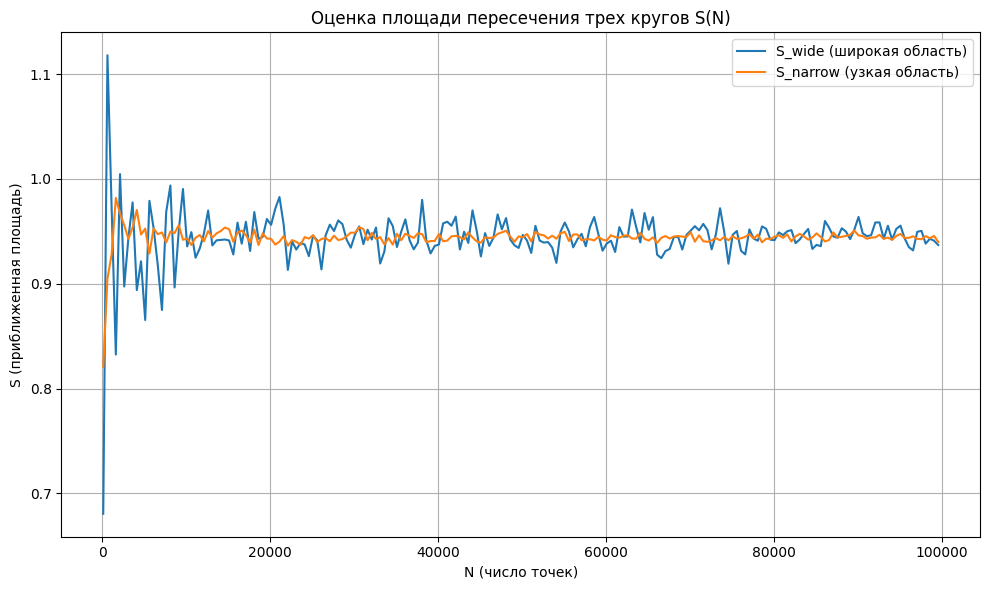

In [6]:
plt.figure(figsize=(10, 6))

plt.plot(df["N"], df["S_wide"],   label="S_wide (широкая область)")
plt.plot(df["N"], df["S_narrow"], label="S_narrow (узкая область)")

plt.xlabel("N (число точек)")
plt.ylabel("S (приближенная площадь)")
plt.title("Оценка площади пересечения трех кругов S(N)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


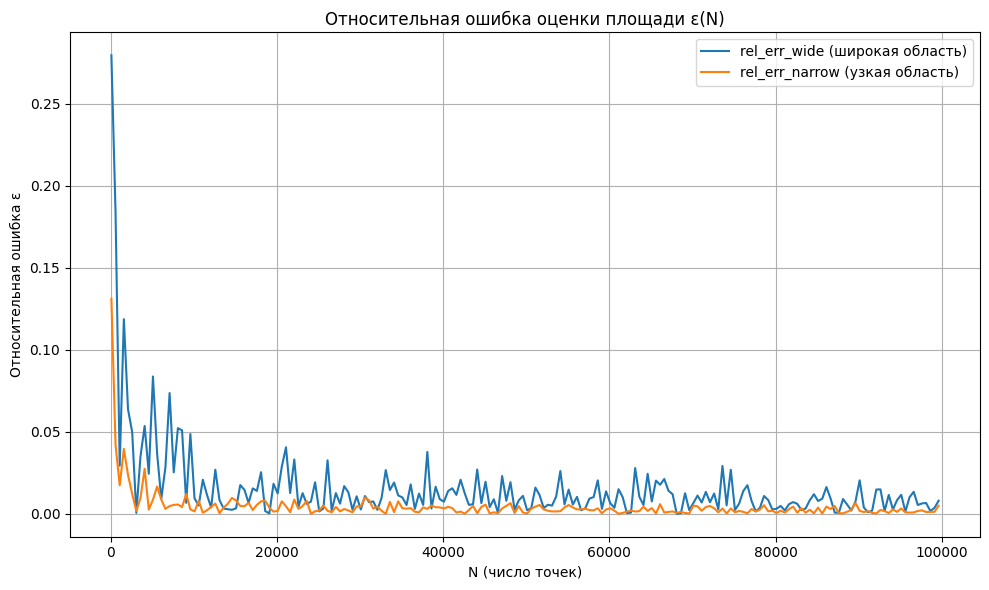

In [7]:
plt.figure(figsize=(10, 6))

plt.plot(df["N"], df["rel_err_wide"],   label="rel_err_wide (широкая область)")
plt.plot(df["N"], df["rel_err_narrow"], label="rel_err_narrow (узкая область)")

plt.xlabel("N (число точек)")
plt.ylabel("Относительная ошибка ε")
plt.title("Относительная ошибка оценки площади ε(N)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
